# Niche Query on CCF Dataset


Experiment setup:
- Niche: k-hop neighboring cells within the same brain section;
- Niche: all neighboring cells within the same brain section;
- Niche: cross brain section k-hop neighbouring cells;
- Positive pairs: samples from the same brain section and visualization by prob.

## Load Data

In [2]:

import logging

# sys.path.insert(0, str(Path.cwd().parent.parent / "src"))
logging.basicConfig(level=logging.INFO)

## Gene Expressions

In [3]:
from src.NicheQueryPrototype.database import Database
from src.NicheQueryPrototype.niche import Niche
from src.NicheQueryPrototype.query import NicheQuery

# step 1: create db
data_folder = 'notebook/ccf/data/zhuang-abca-1/'
target_sample_ids = ['Zhuang-ABCA-1.086', 'Zhuang-ABCA-1.104', 'Zhuang-ABCA-1.102', 'Zhuang-ABCA-1.087',
                  'Zhuang-ABCA-1.090', 'Zhuang-ABCA-1.093', 'Zhuang-ABCA-1.084', 'Zhuang-ABCA-1.088',
                  'Zhuang-ABCA-1.096', 'Zhuang-ABCA-1.097', 'Zhuang-ABCA-1.106', 'Zhuang-ABCA-1.107']
db = Database(target_sample_ids)
db.construct(adata_path=[data_folder + 'Zhuang-ABCA-1-raw.h5ad'],
             cell_metadata_path=[data_folder + 'cell_metadata.csv'],
             ccf_coordinates_path=[data_folder + 'ccf_coordinates.csv'],
             feature_name='gene_expression',
             parcellation_path='notebook/ccf/data/parcellation/structure.json')

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:src.NicheQueryPrototype.database:Loading adata...
INFO:src.NicheQueryPrototype.database:Loading cell metadata...
INFO:src.NicheQueryPrototype.database:Constructing parcellation tree...
INFO:src.NicheQueryPrototype.database:Constructing database for niche query...
INFO:src.NicheQueryPrototype.database:	10000 cells loaded...
INFO:src.NicheQueryPrototype.database:	20000 cells loaded...
INFO:src.NicheQueryPrototype.database:	30000 cells loaded...
INFO:src.NicheQueryPrototype.database:	40000 cells loaded...
INFO:src.NicheQueryPrototype.database:	50000 cells loaded...
INFO:src.NicheQueryPrototype.database:	60000 cells loaded...
INFO:src.NicheQueryPrototype.database:	70000

INFO:src.NicheQueryPrototype.niche:Constructing k-hop graph..
INFO:src.NicheQueryPrototype.niche:Computing niche feature..
INFO:src.NicheQueryPrototype.niche:Finished computing niche feature with 100 cells on Zhuang-ABCA-1.086 slice.
/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:143: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


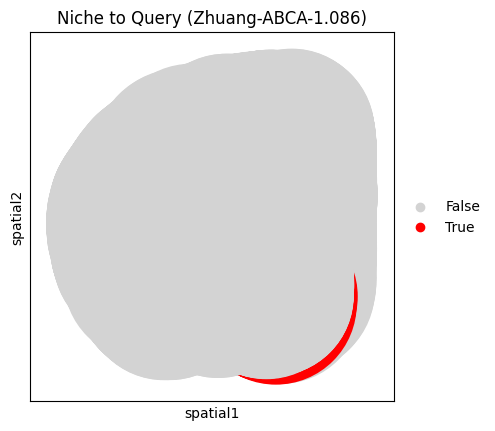

/Users/sheryli/Documents/misc/biology/Ji Lab/ST_FM_benchmark/BenchmarkNicheQuery/src/NicheQueryPrototype/niche.py:149: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


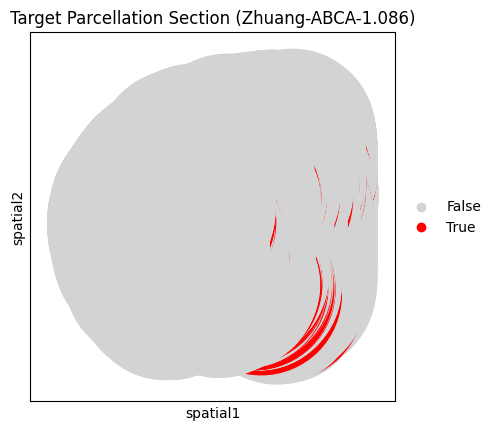

In [4]:
# step 2: construct niche to query

niche_to_query = Niche()
niche_to_query.construct_by_k_hop(db, center_cell_id='44271692540130311954709901940577285312', sample_id='Zhuang-ABCA-1.086', k=10, cell_limit=100,
                                  parcellation_index=987)
niche_to_query.visualize(db)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[DONE] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr

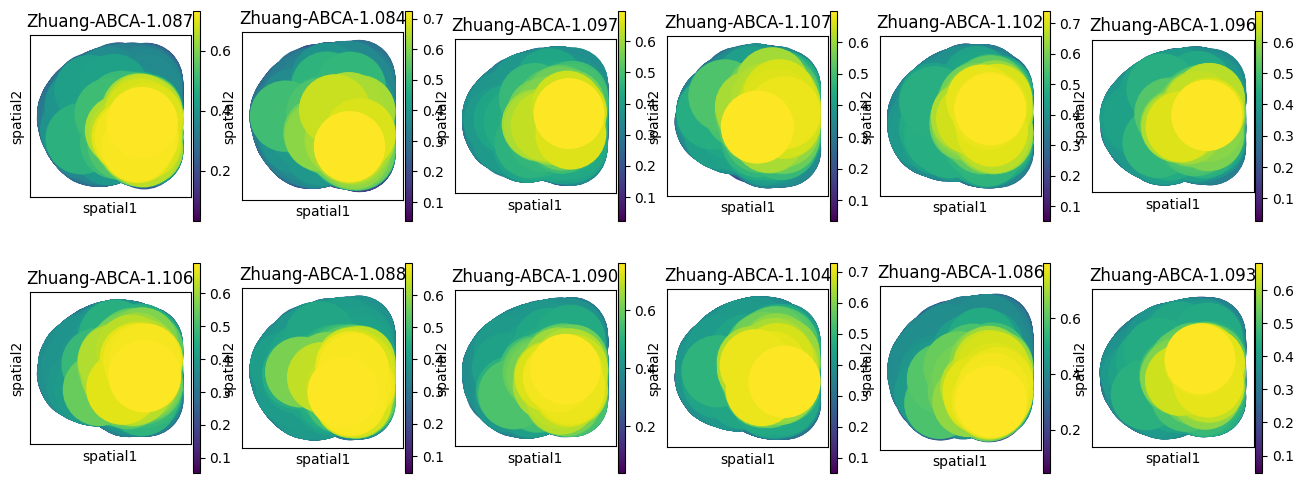

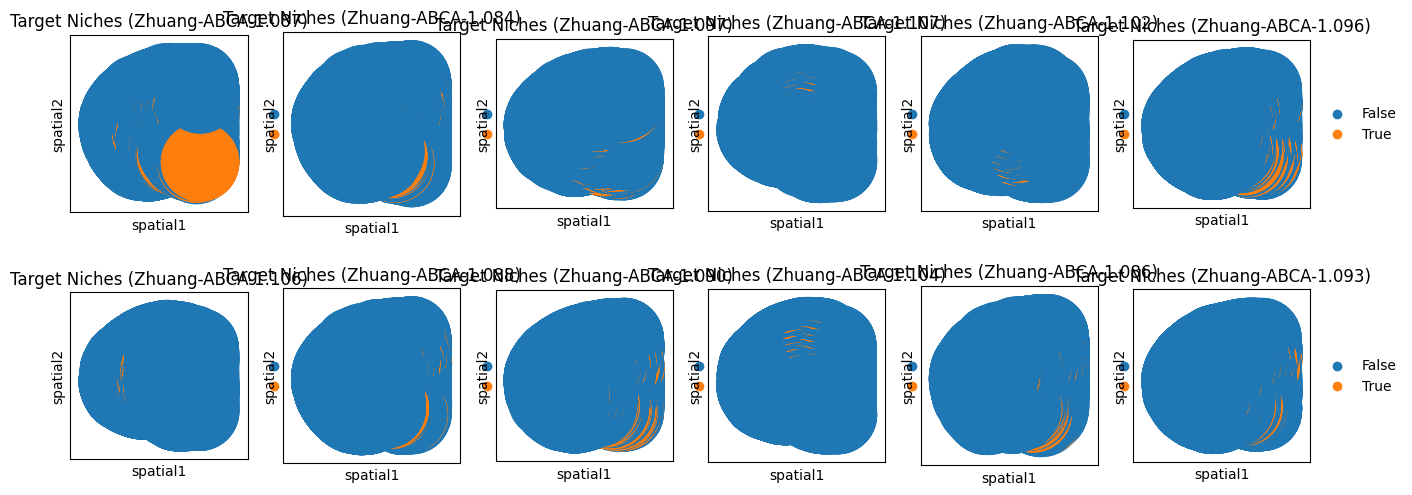

In [7]:
# step 3: run niche query on given samples

niche_query = NicheQuery(db=db, niche=niche_to_query, k=3)
query_samples = [s for s in db.samples.values() if s.id in target_sample_ids]
niche_query.niche_query_visualization(query_samples, show_target_niches=True)

In [10]:
# step 4: classification report
niche_query.niche_query_verification(search_samples=query_samples)

INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.087
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.084
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.097
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.107
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[SKIP] finish sample: Zhuang-ABCA-1.102
INFO:src.NicheQueryPrototype.niche:[START] start computing niche features for sample Zhuang-ABCA-1.096
INFO:sr